<a href="https://colab.research.google.com/github/SanjanaNova/Quantum-Computing-/blob/main/Teleportation_Coding_Presentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer
import numpy as np
from qiskit import *
from qiskit.visualization import plot_state_qsphere, plot_histogram, plot_bloch_multivector, array_to_latex
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer import AerSimulator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.2 MB/s eta 0:00:00


# In this circuit, Alice is teleporting the state of qubit 0 to Bob's qubit 2. Initial state is 0.6|0>+0.8|1>

This circuit requires the following gates: X, H, CX, CZ and measurement operations.

The state that we want to teleport is q0. Alice's half of the Bell pair is - q1 Bob's half of the bell pair is - q2. q2 is the destination

Steps we need to follow to implement this protocol:

Step 1: In q0, prepare the state we want Alice to teleport

Step 2: Create the entanglement betweent Alice and Bob

Step 3: Entangle q0 with Alice's q1 and change the basis of q0 into a superposition state as preparation for Bell measurement.

Step 4: Alice measures both q0 and q1 and stores the results in classical bits c0 and c1

Step 5: Bob's conditional operations based on what was measured and stored by Alice

If, c0c1 = 00, no correction needed, identity operation

c0c1 = 01 then a x/cx gate is used

c0c1 = 10 then z/cz gate is used

c0c1 = 11 then both gates are needed

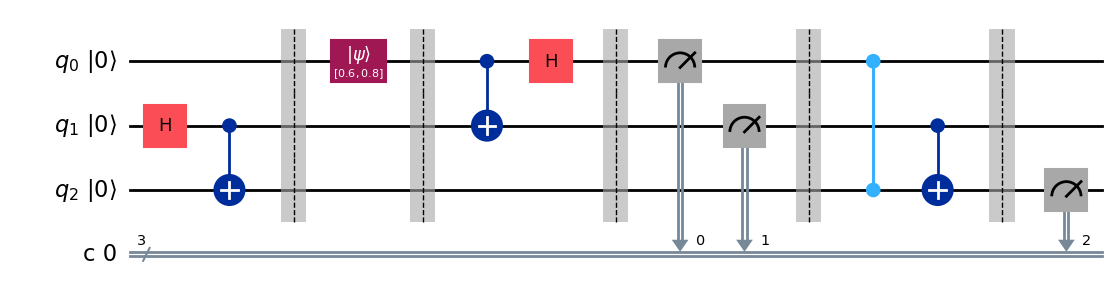

In [2]:
# Create a Quantum Circuit with 3 qubit and 2 classical bit
qc = QuantumCircuit(3,3)

#Qubit ordering
# q0 = State that we want to teleport
# q1 = Alice's half of the Bell pair
# q2 = Bob's half of the Bell pair, the destination of the teleportation


# Step 1: Create Bell pair between qubit 1 and 2
qc.h(1) #apply hadamard gate on qubit 1
qc.cx(1,2) #apply NOT gate with qubit 1 as control and qubit 2 as target
qc.barrier()


# Step 2: Prepare the initial state to be teleported in qubit 0
qc.initialize([0.6,0.8],0)
qc.barrier()


# Step 3: Prepare q0 and q1 for measurement
qc.cx(0,1)  # Apply CNOT gate with qubit 0 as control and qubit 1 as target
qc.h(0)   # Apply Hadamard gate on qubit 0
qc.barrier()



# Step 4: Measure qubit 0 and 1
qc.measure([0,1],[0,1]) #measure qubit 0 and 1 and store result in classical bits 0 and 1.
qc.barrier()


# Step 5: Conditional application gates on qubit 2 depending on the classical bits
qc.cz(0,2)  # Apply CZ gate with qubit 0 as control and qubit 2 as target. Basically applying a Z gate uf the measurement of q0 is 1. Does nothing if the measurement of q0 is 0
qc.cx(1,2)  # Apply CNOT gate with qubit 1 as control and qubit 2 as target. Applies an X gate if the measurement of q1 is 1 and does nothing if measurement of q1 is 0
qc.barrier()
#the main qc protocol ends here

qc.measure(2,2)


qc.draw(output='mpl', initial_state= True)

In [3]:
circ = transpile(qc, AerSimulator())
res = AerSimulator().run(circ, shots =10000).result()
counts = res.get_counts(circ)
print(counts)

{'100': 1548, '101': 1655, '001': 913, '011': 924, '111': 1634, '010': 867, '000': 880, '110': 1579}


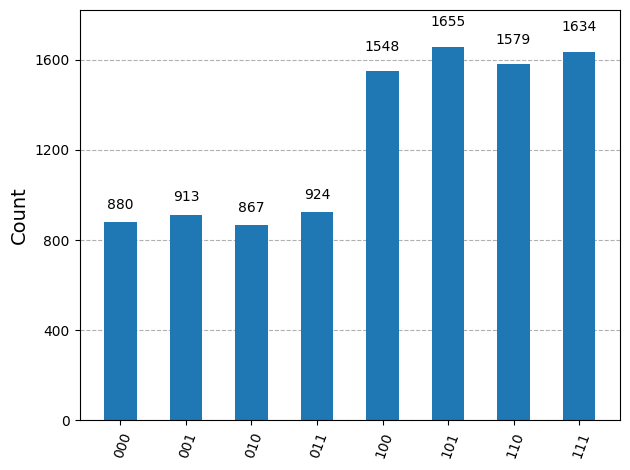

In [4]:
plot_histogram(counts)

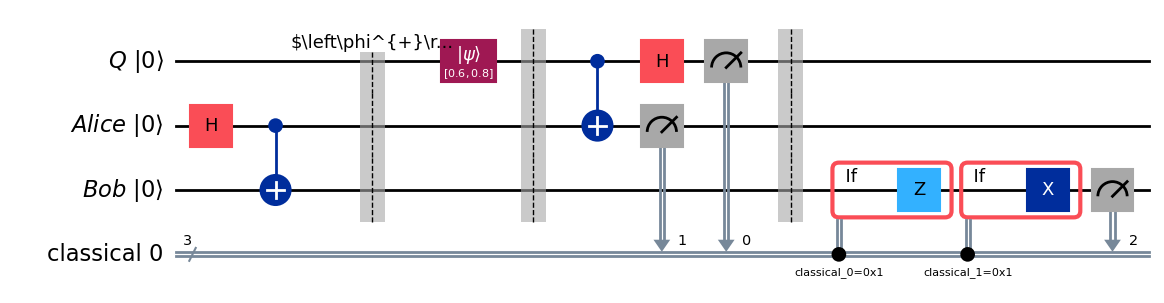

In [5]:
Q = QuantumRegister(1,'Q')
A = QuantumRegister(1,'Alice')
B = QuantumRegister(1,'Bob')
classical = ClassicalRegister(3,'classical')
qc = QuantumCircuit(Q,A,B,classical)

#Bell state preparation
qc.h(A[0])
qc.cx(A[0],B[0])
qc.barrier(label='$\\left\\phi^{+}\\right\\rabgle$')

#initialization of arbitrary state
qc.initialize([0.6,0.8],0)
qc.barrier()

#Alice's Measurement of qubit Q & A
qc.cx(Q[0],A[0])
qc.h(Q[0])
qc.measure(Q[0],classical[0])
qc.measure(A[0],classical[1])
qc.barrier()

#Conditional gates on qubit 2 based on measurements of qubit 0 & 1
with qc.if_test((classical[0],1)):
  qc.z(B[0])#apply cz gate with qubit 0 as control and qubit 2 as target, Basically applying a z gate of the measurement of q0 is 1.
with qc.if_test((classical[1],1)):
  qc.x(B[0])#apply a CNOT gate with qubit 1 as control and qubit 2 as target. applies a Z gate of q1 is 1 and does nothing if measurement is 0.

qc.measure(B[0],classical[2])
qc.draw(output='mpl', initial_state=True)

In [7]:
#In this section, AerSimulator is to be called for visualize the output of the quantum circuit, where tranpile converts the quantum circuit useable for simulator.
from qiskit_aer import AerSimulator
qc = transpile(qc, AerSimulator())
res = AerSimulator().run(qc,shots = 10000).result()
counts= res.get_counts(qc)
print(counts)

{'000': 935, '010': 915, '011': 843, '111': 1617, '001': 876, '110': 1588, '100': 1651, '101': 1575}


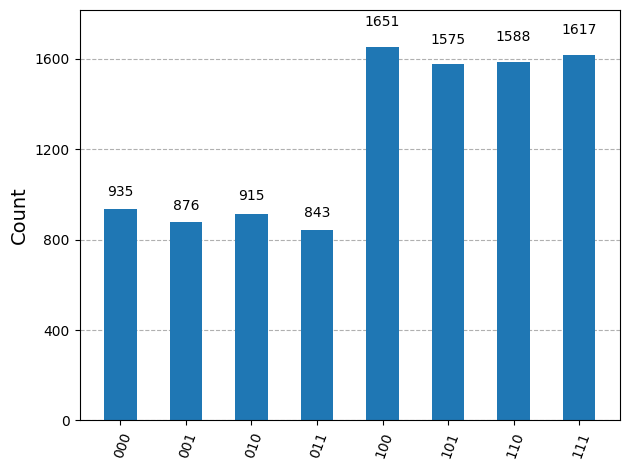

In [8]:
plot_histogram(counts)